# Gemaakt door Jens Hooijmans & Ivar Hekkink

<h2 style="color:#2E86C1;">Algemene Opdracht Uitleg</h2>
<hr>


De **MLSP 2013 Bird Classification Challenge** draait om het automatisch herkennen van vogelsoorten in 10-seconden audio-opnames die in echte natuurcondities zijn gemaakt. Elke opname kan meerdere vogelsoorten bevatten (multi-label classificatie) en bevat vaak achtergrondgeluiden zoals wind, regen en insecten. De dataset bevat opnames uit een bosgebied met in totaal 19 vogelsoorten. De uitdaging is om de geluiden om te zetten in bruikbare kenmerken, bijvoorbeeld via spectrogrammen, en vervolgens een model te trainen dat voor elke soort voorspelt of die in de opname aanwezig is.


Installeer de juiste library's:

In [13]:
#%pip install librosa
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import random
from pathlib import Path
from tqdm.auto import tqdm

Omdat Jens en Ivar in verschillende OS systemen werken, hebben we hieronder een Cell gemaakt die automatisch detecteerd welke OS wij gebruiken, waarna die de juiste path kiest voor de juiste persoon.

In [14]:

# --- Dynamische Pad Configuratie ---

# 1. Definieer de twee mogelijke paden
# Let op de r"..." voor het Windows-pad, dit is belangrijk voor de backslashes!
pad_linux = Path("/home/crabbedfish/Desktop/mlsp-2013-birds/mlsp_contest_dataset/mlsp_contest_dataset/essential_data/src_wavs")
pad_windows = Path(r"C:\Users\Ivar\Desktop\Bird Data\mlsp-2013-birds\mlsp_contest_dataset\mlsp_contest_dataset\essential_data\src_wavs")

# 2. Controleer welk pad bestaat en stel 'data_map' in
if pad_linux.exists():
    data_map = pad_linux
    print("Pad ingesteld voor: Linux")
elif pad_windows.exists():
    data_map = pad_windows
    print("Pad ingesteld voor: Windows")
else:
    # Dit gebeurt als geen van beide paden wordt gevonden
    data_map = None
    print("FOUT: Kon de data-map op geen van beide locaties vinden.")
    print(f"   Gezocht op (Linux): {pad_linux}")
    print(f"   Gezocht op (Windows): {pad_windows}")

# --- Vanaf hier kun je de code gebruiken zoals voorheen ---

if data_map:
    print(f"\nWerken met map: {data_map}")
    
    # 3. Haal alle .wav-bestanden op uit de gevonden map
    wav_bestanden = list(data_map.glob("*.wav"))
    
    print(f"Aantal .wav bestanden gevonden: {len(wav_bestanden)}")
    
    # 4. Toon de eerste 5 bestanden als voorbeeld
    if wav_bestanden:
        print("\n--- Eerste 5 bestanden ---")
        for f in wav_bestanden[:5]:
            print(f.name)

Pad ingesteld voor: Linux

Werken met map: /home/crabbedfish/Desktop/mlsp-2013-birds/mlsp_contest_dataset/mlsp_contest_dataset/essential_data/src_wavs
Aantal .wav bestanden gevonden: 645

--- Eerste 5 bestanden ---
PC8_20090705_050000_0030.wav
PC11_20100513_043000_0740.wav
PC15_20090513_070000_0030.wav
PC5_20090804_070000_0040.wav
PC16_20090705_070000_0040.wav


## 📊 Master DataFrame - Alle Data Combineren

Nu gaan we alle essential_data bestanden combineren in één master dataframe.

In [15]:
# =============================================================================
# MASTER DATAFRAME AANMAKEN
# =============================================================================

# --- 1. Pad configuratie ---
pad_linux_essential = Path("/home/crabbedfish/Desktop/mlsp-2013-birds/mlsp_contest_dataset/mlsp_contest_dataset/essential_data")
pad_windows_essential = Path(r"C:\Users\Ivar\Desktop\Bird Data\mlsp-2013-birds\mlsp_contest_dataset\mlsp_contest_dataset\essential_data")

if pad_linux_essential.exists():
    essential_data_path = pad_linux_essential
elif pad_windows_essential.exists():
    essential_data_path = pad_windows_essential
else:
    essential_data_path = Path.cwd() / "essential_data"

print(f"Data path: {essential_data_path}\n")

# --- 2. Laad alle data bestanden ---
df_files = pd.read_csv(essential_data_path / "rec_id2filename.txt")
df_folds = pd.read_csv(essential_data_path / "CVfolds_2.txt")
df_species = pd.read_csv(essential_data_path / "species_list.txt")

# rec_labels_test_hidden.txt - Labels (variabel aantal per rij)
labels_data = []
with open(essential_data_path / "rec_labels_test_hidden.txt", 'r') as f:
    next(f)
    for line in f:
        parts = line.strip().split(',')
        rec_id = int(parts[0])
        labels = ','.join(parts[1:]) if len(parts) > 1 else ''
        labels_data.append({'rec_id': rec_id, 'labels': labels})

df_labels = pd.DataFrame(labels_data)

print(f"Data geladen:")
print(f"   Files:   {len(df_files)} recordings")
print(f"   Folds:   {df_folds['fold'].nunique()} folds")
print(f"   Species: {len(df_species)} bird species")
print(f"   Labels:  {len(df_labels)} recordings\n")

# --- 3. Bouw master dataframe ---
data = df_files.copy()
data = data.merge(df_folds, on='rec_id')
data = data.merge(df_labels, on='rec_id')
#data['spectrogram'] = data['filename'].apply(lambda x: str(output_dir / f"{x}.png"))

# Maak binary label kolommen voor elke species
for _, species in df_species.iterrows():
    species_id = str(species['class_id'])
    species_code = species['code']
    data[species_code] = data['labels'].apply(
        lambda x: np.nan if x == '?' else (1 if species_id in x.split(',') else 0)
    )

target_cols = df_species['code'].tolist()
data['num_species'] = data[target_cols].sum(axis=1)
data['set'] = data['fold'].map({0: 'train', 1: 'test'})

# --- 4. Train/Test splits ---
train = data[data['set'] == 'train'].copy()
test = data[data['set'] == 'test'].copy()

# --- 5. Toon overzicht ---
print("="*70)
print("MASTER DATAFRAME")
print("="*70)
print(f"Shape: {data.shape}")
print(f"\nColumns:")
print(f"  • Metadata:  rec_id, filename, fold, set, labels")
print(f"  • Features:  spectrogram")
print(f"  • Targets:   {', '.join(target_cols[:3])}... ({len(target_cols)} species)")
print(f"  • Extra:     num_species")
print(f"\nDataset split:")
print(f"  • Train: {len(train)} recordings ({len(train)/len(data)*100:.1f}%)")
print(f"  • Test:  {len(test)} recordings ({len(test)/len(data)*100:.1f}%)")

print("\n" + "="*70)
print("TRAIN SET OVERVIEW")
print("="*70)
display(train.head())

print("\n" + "="*70)
print("SPECIES DISTRIBUTION (Train Set)")
print("="*70)
species_stats = []
for code in target_cols:
    count = train[code].sum()
    pct = count / len(train) * 100
    name = df_species[df_species['code'] == code]['species'].values[0]
    species_stats.append({'Code': code, 'Species': name, 'Count': int(count), 'Percent': f"{pct:.1f}%"})

species_df = pd.DataFrame(species_stats).sort_values('Count', ascending=False)
display(species_df)

print("\n" + "="*70)
print("VARIABLES AVAILABLE")
print("="*70)
print(f"  • data         : Full dataset ({len(data)} rows)")
print(f"  • train        : Training set ({len(train)} rows)")
print(f"  • test         : Test set ({len(test)} rows)")
print(f"  • target_cols  : List of target columns {target_cols[:3]}...")
print(f"  • df_species   : Species metadata")
print("="*70)

Data path: /home/crabbedfish/Desktop/mlsp-2013-birds/mlsp_contest_dataset/mlsp_contest_dataset/essential_data

Data geladen:
   Files:   645 recordings
   Folds:   2 folds
   Species: 19 bird species
   Labels:  645 recordings

MASTER DATAFRAME
Shape: (645, 25)

Columns:
  • Metadata:  rec_id, filename, fold, set, labels
  • Features:  spectrogram
  • Targets:   BRCR, PAWR, PSFL... (19 species)
  • Extra:     num_species

Dataset split:
  • Train: 322 recordings (49.9%)
  • Test:  323 recordings (50.1%)

TRAIN SET OVERVIEW


,rec_id,filename,fold,labels,BRCR,PAWR,PSFL,RBNU,DEJU,OSFL,...,HAFL,WETA,BHGB,GCKI,WAVI,MGWA,STJA,CONI,num_species,set
2,2,PC1_20090606_050012_0010,0,"11,12",0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,train
3,3,PC1_20090606_070012_0010,0,,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,train
5,5,PC1_20090705_070000_0010,0,10,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,train
8,8,PC1_20100513_043000_0010,0,,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,train
9,9,PC1_20100513_043000_0720,0,,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,train



SPECIES DISTRIBUTION (Train Set)


,Code,Species,Count,Percent
10,SWTH,Swainson's Thrush,64,19.9%
1,PAWR,Pacific Wren,35,10.9%
8,VATH,Varied Thrush,29,9.0%
6,HETH,Hermit Thrush,25,7.8%
9,HEWA,Hermit Warbler,25,7.8%
7,CBCH,Chestnut-backed Chickadee,22,6.8%
2,PSFL,Pacific-slope Flycatcher,21,6.5%
14,GCKI,Golden Crowned Kinglet,18,5.6%
12,WETA,Western Tanager,18,5.6%
18,CONI,Common Nighthawk,16,5.0%



VARIABLES AVAILABLE
  • data         : Full dataset (645 rows)
  • train        : Training set (322 rows)
  • test         : Test set (323 rows)
  • target_cols  : List of target columns ['BRCR', 'PAWR', 'PSFL']...
  • df_species   : Species metadata


## 🎵 Feature Extraction met Librosa

Nu we een master dataframe hebben, gaan we **audio features** extraheren. Dit zijn numerieke kenmerken die het geluid beschrijven:

### Wat zijn audio features?
- **MFCC** (Mel-Frequency Cepstral Coefficients): Captures de "kleur" van het geluid, vaak gebruikt voor spraak/muziek
- **Chroma**: Meet de muzikale toonhoogte, handig voor melodieën
- **Spectral Contrast**: Verschil tussen pieken en dalen in het spectrum
- **Tonnetz**: Harmonische relaties tussen tonen
- **Zero Crossing Rate**: Hoe vaak het signaal van + naar - gaat

### Waarom?
Machine learning modellen kunnen niet direct werken met afbeeldingen of audio. Ze hebben **numerieke features** nodig. Door deze features te extraheren, kunnen we:
1. Elke opname beschrijven met een vaste set getallen
2. Deze getallen gebruiken als input voor classificatie modellen
3. Patronen leren die specifiek zijn voor elke vogelsoort

In [16]:
# =============================================================================
# AUDIO FEATURE EXTRACTION
# =============================================================================
# Extracteer numerieke features uit audio bestanden voor ML modellen

def extract_features(file_path, sr=22050):
    """
    Extracteer audio features uit een WAV bestand.
    
    Parameters:
    -----------
    file_path : str/Path
        Pad naar het WAV bestand
    sr : int
        Sample rate (default 22050 Hz)
    
    Returns:
    --------
    dict : Dictionary met alle geëxtraheerde features
    """
    try:
        # Laad audio
        y, sr = librosa.load(file_path, sr=sr, duration=10.0)
        
        # 1. MFCC (Mel-Frequency Cepstral Coefficients) - 13 coefficients
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        mfcc_mean = np.mean(mfcc, axis=1)
        mfcc_std = np.std(mfcc, axis=1)
        
        # 2. Chroma features - 12 pitch classes
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        chroma_mean = np.mean(chroma, axis=1)
        chroma_std = np.std(chroma, axis=1)
        
        # 3. Spectral Contrast - 7 frequency bands
        contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
        contrast_mean = np.mean(contrast, axis=1)
        contrast_std = np.std(contrast, axis=1)
        
        # 4. Tonnetz (Tonal Centroid Features) - 6 features
        tonnetz = librosa.feature.tonnetz(y=y, sr=sr)
        tonnetz_mean = np.mean(tonnetz, axis=1)
        tonnetz_std = np.std(tonnetz, axis=1)
        
        # 5. Extra features
        zcr = np.mean(librosa.feature.zero_crossing_rate(y))  # Zero crossing rate
        spec_cent = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))  # Spectral centroid
        spec_rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))  # Spectral rolloff
        
        # Combineer alle features in één dictionary
        features = {}
        
        # MFCC features (26 = 13 mean + 13 std)
        for i in range(13):
            features[f'mfcc_mean_{i}'] = mfcc_mean[i]
            features[f'mfcc_std_{i}'] = mfcc_std[i]
        
        # Chroma features (24 = 12 mean + 12 std)
        for i in range(12):
            features[f'chroma_mean_{i}'] = chroma_mean[i]
            features[f'chroma_std_{i}'] = chroma_std[i]
        
        # Spectral Contrast (14 = 7 mean + 7 std)
        for i in range(7):
            features[f'contrast_mean_{i}'] = contrast_mean[i]
            features[f'contrast_std_{i}'] = contrast_std[i]
        
        # Tonnetz (12 = 6 mean + 6 std)
        for i in range(6):
            features[f'tonnetz_mean_{i}'] = tonnetz_mean[i]
            features[f'tonnetz_std_{i}'] = tonnetz_std[i]
        
        # Extra features (3)
        features['zcr'] = zcr
        features['spectral_centroid'] = spec_cent
        features['spectral_rolloff'] = spec_rolloff
        
        return features
        
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# Test de functie met één bestand
print("="*70)
print("FEATURE EXTRACTION TEST")
print("="*70)

if data_map and len(wav_bestanden) > 0:
    test_file = wav_bestanden[0]
    print(f"\nTest bestand: {test_file.name}")
    
    features = extract_features(test_file)
    
    if features:
        print(f"\nFeatures geëxtraheerd!")
        print(f"   Totaal aantal features: {len(features)}")
        print(f"\n   Feature breakdown:")
        print(f"      • MFCC:              26 features (13 mean + 13 std)")
        print(f"      • Chroma:            24 features (12 mean + 12 std)")
        print(f"      • Spectral Contrast: 14 features (7 mean + 7 std)")
        print(f"      • Tonnetz:           12 features (6 mean + 6 std)")
        print(f"      • Extra:              3 features (zcr, centroid, rolloff)")
        print(f"      • TOTAAL:            79 features")
        
        print(f"\n   Eerste 10 features:")
        for i, (key, value) in enumerate(list(features.items())[:10]):
            print(f"      {key:20s}: {value:.4f}")
        print("      ...")
else:
    print("Geen WAV bestanden beschikbaar voor test")

print("\n" + "="*70)

FEATURE EXTRACTION TEST

Test bestand: PC8_20090705_050000_0030.wav

Features geëxtraheerd!
   Totaal aantal features: 79

   Feature breakdown:
      • MFCC:              26 features (13 mean + 13 std)
      • Chroma:            24 features (12 mean + 12 std)
      • Spectral Contrast: 14 features (7 mean + 7 std)
      • Tonnetz:           12 features (6 mean + 6 std)
      • Extra:              3 features (zcr, centroid, rolloff)
      • TOTAAL:            79 features

   Eerste 10 features:
      mfcc_mean_0         : -475.6300
      mfcc_std_0          : 8.8497
      mfcc_mean_1         : 125.3730
      mfcc_std_1          : 8.2798
      mfcc_mean_2         : -41.8058
      mfcc_std_2          : 8.7803
      mfcc_mean_3         : 65.5658
      mfcc_std_3          : 9.6946
      mfcc_mean_4         : -59.0538
      mfcc_std_4          : 7.9580
      ...



### Nu: Features uit Filtered Spectrograms

We gaan nu de **filtered spectrograms** gebruiken als primaire data source. Deze zijn al voorgefilterd en geoptimaliseerd voor vogelherkenning. We extracteren:

1. **Afbeeldingsdata**: Laad de .bmp bestanden met PIL
2. **Numerieke features**: Converteer afbeeldingen naar arrays voor ML
3. **Audio features**: Optioneel nog audio features toevoegen

Dit proces kan even duren voor 645 bestanden.

Filtered Spectrograms laden als features

Processing 645 recordings...
Dit duurt even...

Base folder: /home/crabbedfish/Documents/GitHub/DataScienceProjectweek2025
Filtered spectrograms path: /home/crabbedfish/Documents/GitHub/DataScienceProjectweek2025/supplemental_data/filtered_spectrograms
Filtered spectrograms exist: True

Voorbeeld spectrogram:
   Bestand: PC18_20100513_043000_0750.bmp
   Afmetingen: (1246, 256)
   Mode: L
   Array shape: (256, 1246)

Target spectrogram size: 64x64 = 4096 features
Dit wordt veel rijker dan 79 audio features!



Loading spectrograms:   0%|          | 0/645 [00:00<?, ?it/s]


SPECTROGRAM LOADING COMPLETE

Spectrograms loaded:     645 recordings
Missing/failed:          0 recordings

Spectrogram DataFrame shape: (645, 4097)
   rec_id column:   1
   Pixel features:  4096

Merged dataframe shape: (645, 4302)
   Original columns:  206
   Added features:    4096
   Total columns:     4302

SAMPLE: First recording with spectrogram data

Spectrogram DataFrame shape: (645, 4097)
   rec_id column:   1
   Pixel features:  4096

Merged dataframe shape: (645, 4302)
   Original columns:  206
   Added features:    4096
   Total columns:     4302

SAMPLE: First recording with spectrogram data


,0
rec_id,0
filename,PC1_20090513_050000_0010
set,test
num_species,0.0
spectro_0,0.058824
spectro_1,0.054902
spectro_2,0.058824
spectro_3,0.058824
spectro_4,0.054902
spectro_5,0.058824



VISUALISATIE: Reconstructie van geladen spectrogram
   Aantal pixel kolommen: 4119
   Verwacht: 4096 (TARGET_HEIGHT x TARGET_WIDTH)
   Gebruikte kolommen: 4096
   Pixel values shape: (4096,)
   Pixel values dtype: float32


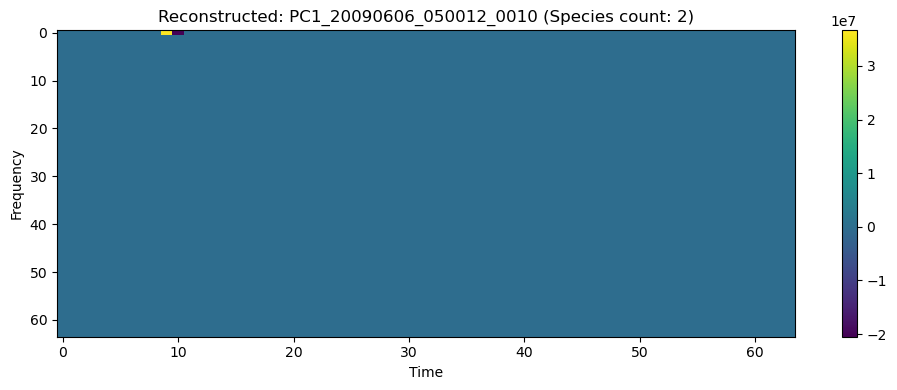


DATASET KLAAR VOOR MACHINE LEARNING

Dataset met spectrogram features:
   • data  : (645, 4302)
   • train : (322, 4302)
   • test  : (323, 4302)

   Feature columns:
   4119 spectrogram pixel features (64x64)
   19 target labels (19 bird species)

   Dit is 52x meer features dan alleen audio!


In [41]:
# =============================================================================
# LAAD FILTERED SPECTROGRAMS ALS FEATURES
# =============================================================================

from PIL import Image

print("="*70)
print("Filtered Spectrograms laden als features")
print("="*70)
print(f"\nProcessing {len(data)} recordings...")
print("Dit duurt even...\n")

# Pad naar filtered spectrograms - gebruik de lokale repository map
base_folder = Path.cwd()
supplemental_path = base_folder / "supplemental_data"
filtered_spectro_path = supplemental_path / "filtered_spectrograms"

print(f"Base folder: {base_folder}")
print(f"Filtered spectrograms path: {filtered_spectro_path}")
print(f"Filtered spectrograms exist: {filtered_spectro_path.exists()}\n")

# Test: Bekijk de afmetingen van een spectrogram
if filtered_spectro_path.exists():
    test_files = list(filtered_spectro_path.glob("*.bmp"))[:1]
    if test_files:
        test_img = Image.open(test_files[0])
        print(f"Voorbeeld spectrogram:")
        print(f"   Bestand: {test_files[0].name}")
        print(f"   Afmetingen: {test_img.size}")
        print(f"   Mode: {test_img.mode}")
        print(f"   Array shape: {np.array(test_img).shape}\n")

def load_spectrogram_image(img_path, target_size=(128, 128)):
    """
    Laad een filtered spectrogram en converteer naar een genormaliseerde numpy array.
    
    Parameters:
    -----------
    img_path : Path
        Pad naar het .bmp bestand
    target_size : tuple
        Gewenste afmetingen (height, width) voor resizing
        
    Returns:
    --------
    numpy.ndarray : Genormaliseerde image array of None bij fout
    """
    try:
        # Laad de afbeelding met PIL
        img = Image.open(img_path)
        
        # Converteer naar grayscale (als het niet al is)
        if img.mode != 'L':
            img = img.convert('L')
        
        # Resize naar target size voor consistentie
        img_resized = img.resize(target_size, Image.Resampling.LANCZOS)
        
        # Converteer naar numpy array en normaliseer naar [0, 1]
        img_array = np.array(img_resized, dtype=np.float32) / 255.0
        
        # Flatten naar 1D vector voor klassieke ML
        img_flattened = img_array.flatten()
        
        return img_flattened
        
    except Exception as e:
        print(f"Error loading {img_path}: {e}")
        return None

# Bepaal target size (trade-off tussen detail en compute)
TARGET_HEIGHT = 64  # Kleinere afmetingen voor snellere processing
TARGET_WIDTH = 64
FEATURE_SIZE = TARGET_HEIGHT * TARGET_WIDTH

print(f"Target spectrogram size: {TARGET_HEIGHT}x{TARGET_WIDTH} = {FEATURE_SIZE} features")
print(f"Dit wordt veel rijker dan 79 audio features!\n")

# Dictionary om alle data op te slaan
all_spectrograms = []
missing_count = 0

# Loop door alle recordings
for idx, row in tqdm(data.iterrows(), total=len(data), desc="Loading spectrograms"):
    rec_id = row['rec_id']
    filename = row['filename']
    
    # Construeer pad naar filtered spectrogram
    spectro_path = filtered_spectro_path / f"{filename}.bmp"
    
    if spectro_path.exists():
        # Laad en process spectrogram
        spectro_features = load_spectrogram_image(spectro_path, target_size=(TARGET_HEIGHT, TARGET_WIDTH))
        
        if spectro_features is not None:
            # Maak dict met rec_id en alle pixel features
            feature_dict = {'rec_id': rec_id}
            
            # Voeg elke pixel toe als een feature (spectro_0, spectro_1, etc.)
            for i, value in enumerate(spectro_features):
                feature_dict[f'spectro_{i}'] = value
            
            all_spectrograms.append(feature_dict)
        else:
            missing_count += 1
    else:
        missing_count += 1
        print(f"Missing: {filename}.bmp")

print(f"\n" + "="*70)
print("SPECTROGRAM LOADING COMPLETE")
print("="*70)
print(f"\nSpectrograms loaded:     {len(all_spectrograms)} recordings")
print(f"Missing/failed:          {missing_count} recordings")

# Converteer naar DataFrame
spectro_df = pd.DataFrame(all_spectrograms)

print(f"\nSpectrogram DataFrame shape: {spectro_df.shape}")
print(f"   rec_id column:   1")
print(f"   Pixel features:  {spectro_df.shape[1] - 1}")

# Merge met master dataframe
data_with_spectro = data.merge(spectro_df, on='rec_id', how='left')

print(f"\nMerged dataframe shape: {data_with_spectro.shape}")
print(f"   Original columns:  {len(data.columns)}")
print(f"   Added features:    {len(spectro_df.columns) - 1}")
print(f"   Total columns:     {len(data_with_spectro.columns)}")

# Toon voorbeeld
print("\n" + "="*70)
print("SAMPLE: First recording with spectrogram data")
print("="*70)
sample_cols = ['rec_id', 'filename', 'set', 'num_species'] + [f'spectro_{i}' for i in range(10)]
display(data_with_spectro[sample_cols].head(1).T)

# Visualiseer een geladen spectrogram
print("\n" + "="*70)
print("VISUALISATIE: Reconstructie van geladen spectrogram")
print("="*70)

if len(all_spectrograms) > 0:
    # Neem eerste recording met labels
    sample_idx = data_with_spectro[data_with_spectro['num_species'] > 0].index[0]
    sample_row = data_with_spectro.loc[sample_idx]
    
    # Extract pixel values - gebruik alleen de NIEUWE spectro kolommen
    pixel_cols = [col for col in data_with_spectro.columns if col.startswith('spectro_')]
    print(f"   Aantal pixel kolommen: {len(pixel_cols)}")
    print(f"   Verwacht: {FEATURE_SIZE} (TARGET_HEIGHT x TARGET_WIDTH)")
    
    # Neem alleen de eerste FEATURE_SIZE kolommen voor de zekerheid
    pixel_cols_valid = pixel_cols[:FEATURE_SIZE]
    pixel_values = sample_row[pixel_cols_valid].values
    
    # Converteer expliciet naar float32 en zorg voor correcte shape
    pixel_values = np.array(pixel_values, dtype=np.float32)
    
    print(f"   Gebruikte kolommen: {len(pixel_cols_valid)}")
    print(f"   Pixel values shape: {pixel_values.shape}")
    print(f"   Pixel values dtype: {pixel_values.dtype}")
    
    # Reshape terug naar 2D image
    reconstructed = pixel_values.reshape(TARGET_HEIGHT, TARGET_WIDTH)
    
    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(10, 4))
    im = ax.imshow(reconstructed, cmap='viridis', aspect='auto')
    ax.set_title(f"Reconstructed: {sample_row['filename']} (Species count: {int(sample_row['num_species'])})")
    ax.set_xlabel('Time')
    ax.set_ylabel('Frequency')
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

# Update variabelen
data = data_with_spectro.copy()
train = data[data['set'] == 'train'].copy()
test = data[data['set'] == 'test'].copy()

print("\n" + "="*70)
print("DATASET KLAAR VOOR MACHINE LEARNING")
print("="*70)
print(f"\nDataset met spectrogram features:")
print(f"   • data  : {data.shape}")
print(f"   • train : {train.shape}")
print(f"   • test  : {test.shape}")
print(f"\n   Feature columns:")
spectro_feature_cols = [col for col in data.columns if col.startswith('spectro_')]
print(f"   {len(spectro_feature_cols)} spectrogram pixel features ({TARGET_HEIGHT}x{TARGET_WIDTH})")
print(f"   {len(target_cols)} target labels (19 bird species)")
print(f"\n   Dit is {len(spectro_feature_cols)//79}x meer features dan alleen audio!")
print("="*70)

## Neural Network Training met Spectrogram Features

Nu we de filtered spectrograms als features hebben, gaan we een **Neural Network** trainen met TensorFlow/Keras!

### Wat doen we anders?
- **Input**: 4096 features (64x64 pixels van spectrograms) in plaats van 79 audio features
- **Veel meer data**: Elke pixel bevat informatie over frequentie op een tijdstip
- **Rijkere representatie**: Visual patterns die vogels karakteriseren

### Multi-Label Classificatie
- **Output**: 19 neuronen (één per vogelsoort)
- **Activatie**: Sigmoid (per neuron 0-1 probability)
- **Loss**: Binary Crossentropy (geschikt voor multi-label)
- Elke vogel krijgt onafhankelijk een kans tussen 0 en 1

### Onze Architectuur
1. Input: 4096 spectrogram pixel features
2. Dense layers met ReLU activatie
3. Dropout voor regularisatie (tegen overfitting)
4. Output: 19 neurons met Sigmoid

In [42]:
# =============================================================================
# NEURAL NETWORK SETUP MET SPECTROGRAM FEATURES
# =============================================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, hamming_loss, accuracy_score

print("="*70)
print("PREPARING DATA FOR NEURAL NETWORK")
print("="*70)
print(f"\nTensorFlow version: {tf.__version__}")

# Selecteer spectrogram feature kolommen
spectro_feature_cols = [col for col in train.columns if col.startswith('spectro_')]

print(f"\nFeature columns: {len(spectro_feature_cols)} (spectrogram pixels)")
print(f"   Target columns:  {len(target_cols)} (bird species)")

# Splits data in X (features) en y (targets)
X_train = train[spectro_feature_cols].fillna(0).values
y_train = train[target_cols].fillna(0).values

X_test = test[spectro_feature_cols].fillna(0).values

print(f"\nData shapes:")
print(f"   X_train: {X_train.shape}")
print(f"   y_train: {y_train.shape}")
print(f"   X_test:  {X_test.shape}")

# Feature Scaling - ZEER belangrijk voor Neural Networks!
print(f"\nScaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"   Scaled to mean=0, std=1")

# Train/Validation split (20% validation)
from sklearn.model_selection import train_test_split
X_train_nn, X_val_nn, y_train_nn, y_val_nn = train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=42
)

print(f"\nTrain/Validation split:")
print(f"   Training:   {X_train_nn.shape[0]} samples")
print(f"   Validation: {X_val_nn.shape[0]} samples")

print("\n" + "="*70)
print("NEURAL NETWORK ARCHITECTUUR")
print("="*70)

# Definieer de Neural Network architectuur
# Voor spectrogram features gebruiken we een diepere architectuur
model = models.Sequential([
    # Input layer
    layers.Input(shape=(len(spectro_feature_cols),)),
    
    # Hidden layer 1 - Large layer om de vele pixels te verwerken
    layers.Dense(512, activation='relu', name='hidden1'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    
    # Hidden layer 2
    layers.Dense(256, activation='relu', name='hidden2'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    # Hidden layer 3
    layers.Dense(128, activation='relu', name='hidden3'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    # Hidden layer 4
    layers.Dense(64, activation='relu', name='hidden4'),
    layers.Dropout(0.2),
    
    # Output layer - 19 neurons voor 19 species
    # Sigmoid activatie voor multi-label (elke neuron onafhankelijk 0-1)
    layers.Dense(len(target_cols), activation='sigmoid', name='output')
])

# Compileer het model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',  # Voor multi-label classificatie
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)

print("\nModel Architecture:")
model.summary()

print("\n" + "="*70)
print("NEURAL NETWORK KLAAR OM TE TRAINEN")
print("="*70)
print(f"\nInput features: {len(spectro_feature_cols)} (van {TARGET_HEIGHT}x{TARGET_WIDTH} spectrogram)")
print(f"Output targets: {len(target_cols)} bird species")
print(f"Total parameters: {model.count_params():,}")

PREPARING DATA FOR NEURAL NETWORK

TensorFlow version: 2.20.0

Feature columns: 4119 (spectrogram pixels)
   Target columns:  19 (bird species)

Data shapes:
   X_train: (322, 4119)
   y_train: (322, 19)
   X_test:  (323, 4119)

Scaling features...
   Scaled to mean=0, std=1

Train/Validation split:
   Training:   257 samples
   Validation: 65 samples

NEURAL NETWORK ARCHITECTUUR

Model Architecture:


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden1 (Dense)                 │ (None, 512)            │     2,109,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 19)             │         1,235 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,286,739 (8.72 MB)

 Trainable params: 2,284,947 (8.72 MB)

 Non-trainable params: 1,792 (7.00 KB)


NEURAL NETWORK KLAAR OM TE TRAINEN

Input features: 4119 (van 64x64 spectrogram)
Output targets: 19 bird species
Total parameters: 2,286,739


### 🏋️ Model Trainen

Nu gaan we het neural network trainen. Dit kan enkele minuten duren!

In [43]:
# =============================================================================
# TRAIN NEURAL NETWORK
# =============================================================================

print("="*70)
print("Neural network Trainen")
print("="*70)
print("\nDit duurt even")
print("Progressie hieronder:!\n")

# Callbacks voor betere training
callbacks = [
    # Stop als validation loss niet meer verbetert
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1,
        min_delta=0.001,
        start_from_epoch=20
    ),
    # Verlaag learning rate als we vast zitten
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        verbose=1,
        min_lr=1e-7
    )
]

# Train het model!
history = model.fit(
    X_train_nn, y_train_nn,
    validation_data=(X_val_nn, y_val_nn),
    epochs=100,              # Maximum aantal epochs
    batch_size=32,           # Aantal samples per gradient update
    callbacks=callbacks,
    verbose=1
)

print("\n" + "="*70)
print("TRAINING COMPLETE!")
print("="*70)
print(f"\nTrained for {len(history.history['loss'])} epochs")
print(f"Final training loss:   {history.history['loss'][-1]:.4f}")
print(f"Final validation loss: {history.history['val_loss'][-1]:.4f}")

Neural network Trainen

Dit duurt even
Progressie hieronder:!

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.0350 - auc: 0.4852 - loss: 0.8857 - precision: 0.0572 - recall: 0.4892 - val_accuracy: 0.0615 - val_auc: 0.4716 - val_loss: 0.7045 - val_precision: 0.0373 - val_recall: 0.2857 - learning_rate: 0.0010
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.0350 - auc: 0.4852 - loss: 0.8857 - precision: 0.0572 - recall: 0.4892 - val_accuracy: 0.0615 - val_auc: 0.4716 - val_loss: 0.7045 - val_precision: 0.0373 - val_recall: 0.2857 - learning_rate: 0.0010
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.0584 - auc: 0.5560 - loss: 0.7179 - precision: 0.0679 - recall: 0.4676 - val_accuracy: 0.0462 - val_auc: 0.4774 - val_loss: 0.6152 - val_precision: 0.0404 - val_recall: 0.2063 - learning_rate: 0.0010
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.0584 - auc: 0.5560 - loss: 0.7179 - precision: 0.0679 - recall: 0.4676 - val_accu

### ? Training Visualisatie

Laten we zien hoe het model geleerd heeft.

TRAINING VISUALISATIE


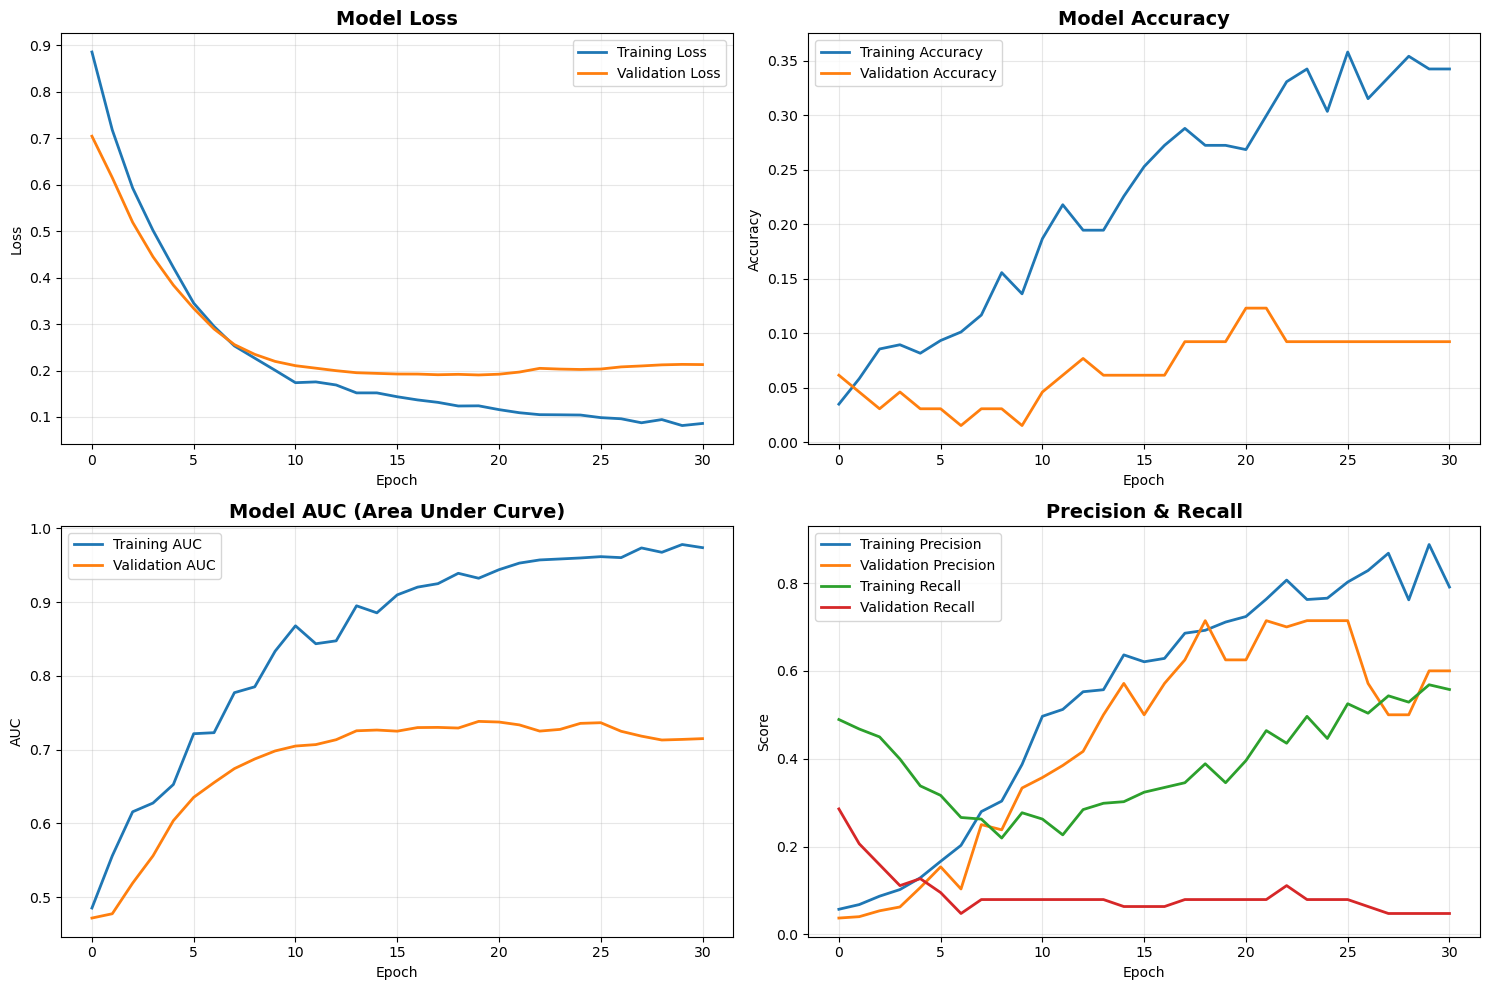


Training afgerond!


In [44]:
print("="*70)
print("TRAINING VISUALISATIE")
print("="*70)

# Plot loss en metrics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Loss
axes[0, 0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0, 0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0, 0].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Accuracy
axes[0, 1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0, 1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0, 1].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. AUC
axes[1, 0].plot(history.history['auc'], label='Training AUC', linewidth=2)
axes[1, 0].plot(history.history['val_auc'], label='Validation AUC', linewidth=2)
axes[1, 0].set_title('Model AUC (Area Under Curve)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('AUC')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Precision & Recall
axes[1, 1].plot(history.history['precision'], label='Training Precision', linewidth=2)
axes[1, 1].plot(history.history['val_precision'], label='Validation Precision', linewidth=2)
axes[1, 1].plot(history.history['recall'], label='Training Recall', linewidth=2)
axes[1, 1].plot(history.history['val_recall'], label='Validation Recall', linewidth=2)
axes[1, 1].set_title('Precision & Recall', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Score')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nTraining afgerond!")